   studyhours  attendance  pastscore  internet  sleephours  passed
0           2          65         55         1           6       0
1           3          70         60         1           7       0
2           4          75         62         1           7       1
3           5          80         68         1           6       1
4           6          85         72         1           7       1
studyhours    int64
attendance    int64
pastscore     int64
internet      int64
sleephours    int64
passed        int64
dtype: object
Classification report  
 

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

Cofussion matrix 
 
 
[[2 1]
 [0 1]]


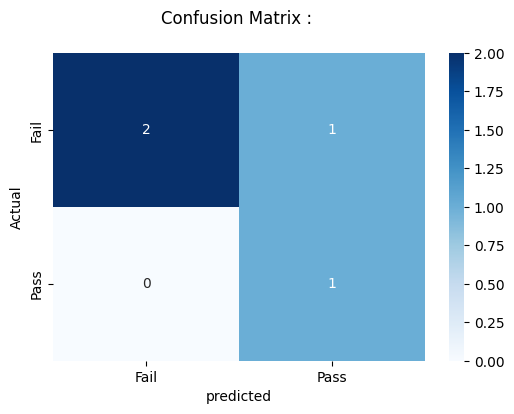

predict your result : 



enter study hours: 2
enter study attenednce: 65
enter study p_score: 55
enter study sleep hours: 6


prediction Based on input : Fail


C:\Users\astha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [10]:
# HOW TO KNOW IF WE WANT FWATURE SCALING OR NOT -> IF WE FIND, ANY OF THE COLUMN HAS HIGH VALUES MACHINE CAN UNDERSTAND THAT COLUMN MUST BE IMPORTANT 
#                                               BUT IT CAN BE OR  NOT 



import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


data = [
{"studyhours":2, "attendance":65, "pastscore":55, "internet":1, "sleephours":6, "passed":0},
{"studyhours":3, "attendance":70, "pastscore":60, "internet":1, "sleephours":7, "passed":0},
{"studyhours":4, "attendance":75, "pastscore":62, "internet":1, "sleephours":7, "passed":1},
{"studyhours":5, "attendance":80, "pastscore":68, "internet":1, "sleephours":6, "passed":1},
{"studyhours":6, "attendance":85, "pastscore":72, "internet":1, "sleephours":7, "passed":1},
{"studyhours":1, "attendance":60, "pastscore":50, "internet":0, "sleephours":5, "passed":0},
{"studyhours":2, "attendance":68, "pastscore":58, "internet":0, "sleephours":6, "passed":0},
{"studyhours":3, "attendance":72, "pastscore":61, "internet":1, "sleephours":7, "passed":1},
{"studyhours":4, "attendance":78, "pastscore":65, "internet":1, "sleephours":6, "passed":1},
{"studyhours":5, "attendance":82, "pastscore":70, "internet":1, "sleephours":7, "passed":1},
{"studyhours":6, "attendance":88, "pastscore":75, "internet":1, "sleephours":8, "passed":1},
{"studyhours":2, "attendance":66, "pastscore":56, "internet":0, "sleephours":6, "passed":0},
{"studyhours":3, "attendance":74, "pastscore":63, "internet":1, "sleephours":7, "passed":1},
{"studyhours":4, "attendance":79, "pastscore":67, "internet":1, "sleephours":6, "passed":1},
{"studyhours":5, "attendance":83, "pastscore":71, "internet":1, "sleephours":7, "passed":1},
{"studyhours":1, "attendance":58, "pastscore":48, "internet":0, "sleephours":5, "passed":0},
{"studyhours":2, "attendance":64, "pastscore":54, "internet":0, "sleephours":6, "passed":0},
{"studyhours":3, "attendance":73, "pastscore":60, "internet":1, "sleephours":7, "passed":1},
{"studyhours":4, "attendance":77, "pastscore":66, "internet":1, "sleephours":6, "passed":1},
{"studyhours":5, "attendance":81, "pastscore":69, "internet":1, "sleephours":7, "passed":1}
]

df = pd.DataFrame(data)
print(df.head())
print(df.dtypes)

featurs = ['studyhours', 'attendance', 'pastscore', 'sleephours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[featurs] = scaler.fit_transform(df[featurs])

X = df_scaled[featurs]
y = df_scaled['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification report  \n \n")
print(classification_report(y_test, y_pred))
print("Cofussion matrix \n \n ")

c_matrix = confusion_matrix(y_test, y_pred)
print(c_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(c_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix : \n")
plt.show()

print("predict your result : \n")
try:
    study_h = float(input("enter study hours:"))
    attand = float(input("enter study attenednce:"))
    p_score = float(input("enter study p_score:"))
    sleep_h = float(input("enter study sleep hours:"))

    user_input =pd.DataFrame([{
        'studyhours' : study_h,
        'attendance' : attand,
        'pastscore' : p_score,
        'sleephours' : sleep_h
    }])

    user_input_scaled = scaler.transform(user_input)
    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction==1 else "Fail"
    print(f'prediction Based on input : {result}')
except Exception as e:
    print(e)